<a href="https://colab.research.google.com/github/Atharv-1905/Machine-Learning/blob/practice/Practice_assignment1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from xgboost import XGBRegressor
from sklearn.linear_model import LinearRegression, LogisticRegression, Ridge, Lasso, ElasticNet
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import root_mean_squared_error, r2_score, accuracy_score, classification_report
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
SEED = 42

In [ ]:
train_df = pd.read_csv('train_dataset.csv')
test_df = pd.read_csv('test_dataset.csv')

In [ ]:
display(train_df.head())
display(test_df.head())

,flow_rate_L_min,concentration_mol_L,inlet_temperature_K,length_m,jacket_temperature_K,overall_yield
0,33.09,3.68,357.75,19.87,383.79,63.024
1,76.30,1.34,429.70,14.84,405.72,86.611
2,59.90,1.01,431.10,11.76,385.40,86.347
3,49.90,2.21,445.61,22.85,367.74,92.175
4,16.70,3.95,458.91,4.56,374.13,82.211


,flow_rate_L_min,concentration_mol_L,inlet_temperature_K,length_m,jacket_temperature_K
0,43.73,2.88,454.18,7.66,440.61
1,47.80,2.33,401.37,19.95,390.13
2,7.14,0.65,411.86,3.05,476.23
3,17.86,1.28,385.97,22.36,353.56
4,56.40,2.51,495.33,8.36,517.71


In [ ]:

TARGET_COL = 'overall_yield'

In [ ]:
train_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 6 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   flow_rate_L_min       150 non-null    float64
 1   concentration_mol_L   150 non-null    float64
 2   inlet_temperature_K   150 non-null    float64
 3   length_m              150 non-null    float64
 4   jacket_temperature_K  150 non-null    float64
 5   overall_yield         150 non-null    float64
dtypes: float64(6)
memory usage: 7.2 KB


In [ ]:
train_df.describe()

,flow_rate_L_min,concentration_mol_L,inlet_temperature_K,length_m,jacket_temperature_K,overall_yield
count,150.000000,150.000000,150.000000,150.000000,150.000000,150.000000
mean,40.466800,2.311333,424.423400,14.086533,442.240800,36.222173
std,22.239772,1.019844,45.200641,6.995343,55.047768,38.427427
min,5.410000,0.520000,351.630000,2.260000,354.010000,0.000000
25%,21.112500,1.362500,387.255000,8.027500,393.327500,0.013500
50%,38.610000,2.445000,425.630000,14.235000,437.080000,15.314000
75%,61.227500,3.155000,462.972500,20.685000,486.180000,74.876500
max,79.020000,3.970000,498.580000,24.990000,547.990000,99.971000


In [ ]:
train_df.isna().sum()

,0
flow_rate_L_min,0
concentration_mol_L,0
inlet_temperature_K,0
length_m,0
jacket_temperature_K,0
overall_yield,0


In [ ]:
X = train_df.drop(columns=[TARGET_COL])
y = train_df[TARGET_COL]

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=SEED)

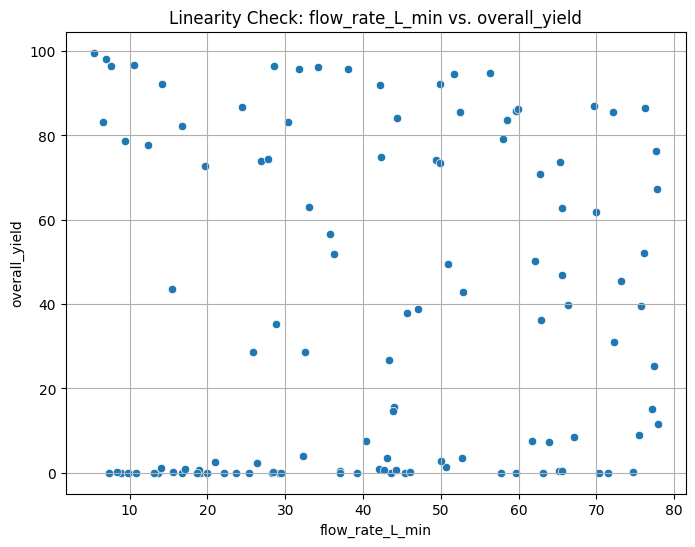

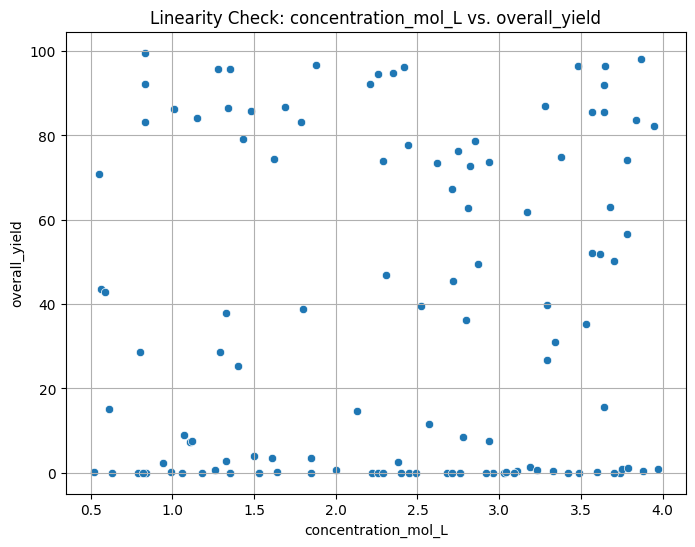

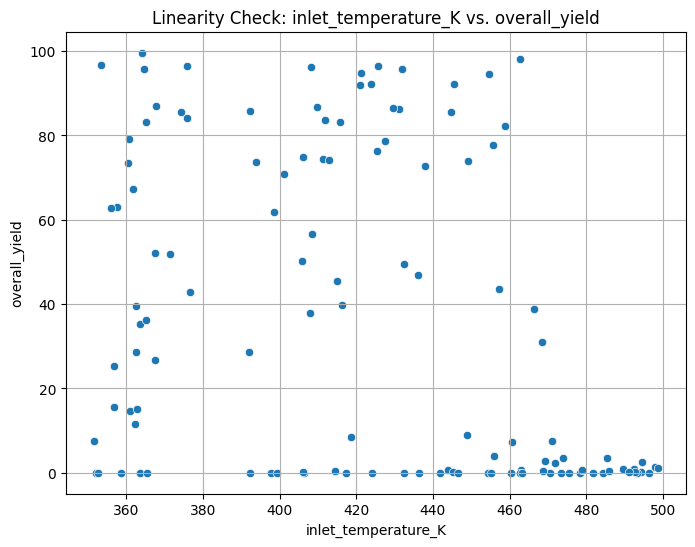

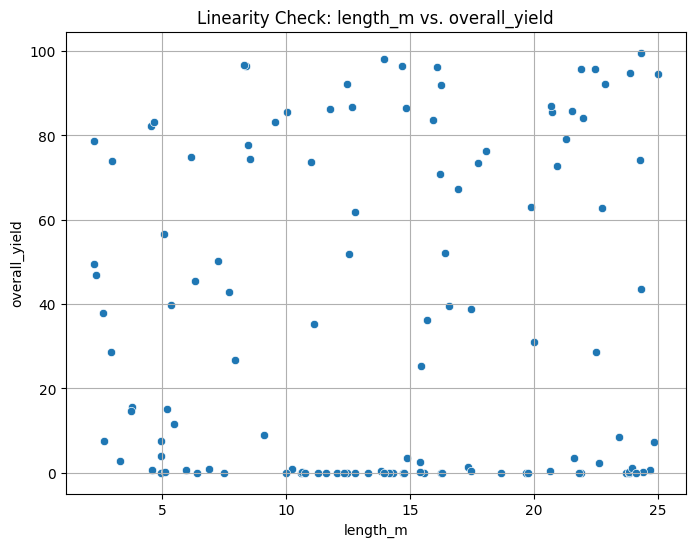

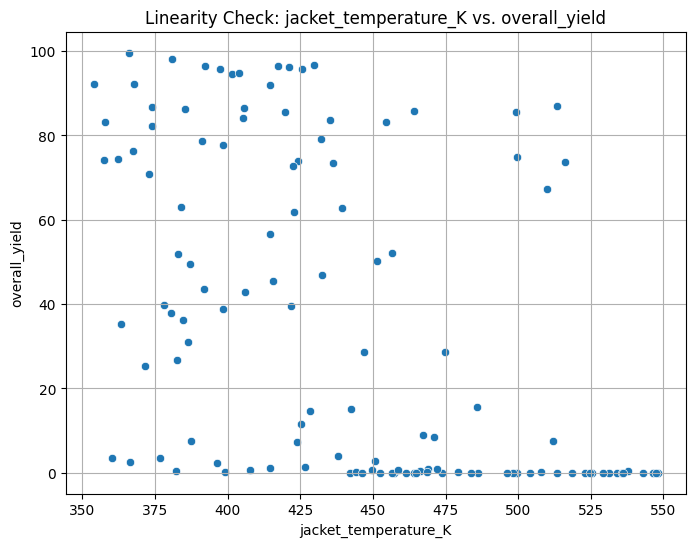

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
for col in X_train.columns:
    plt.figure(figsize=(8, 6))
    sns.scatterplot(x=X_train[col], y=y_train)
    plt.title(f'Linearity Check: {col} vs. {TARGET_COL}')
    plt.xlabel(col)
    plt.ylabel(TARGET_COL)
    plt.grid(True)
    plt.show()

### Feature Engineering: Thermal & Heat Transfer Features

In [ ]:
# Temperature Difference
X_train['temperature_difference'] = X_train['inlet_temperature_K'] - X_train['jacket_temperature_K']
X_test['temperature_difference'] = X_test['inlet_temperature_K'] - X_test['jacket_temperature_K']

# Arrhenius Reciprocals
X_train['inlet_temp_arrhenius'] = 1 / X_train['inlet_temperature_K']
X_test['inlet_temp_arrhenius'] = 1 / X_test['inlet_temperature_K']
X_train['jacket_temp_arrhenius'] = 1 / X_train['jacket_temperature_K']
X_test['jacket_temp_arrhenius'] = 1 / X_test['jacket_temperature_K']

# Temperature Ratio
X_train['temperature_ratio'] = X_train['inlet_temperature_K'] / X_train['jacket_temperature_K']
X_test['temperature_ratio'] = X_test['inlet_temperature_K'] / X_test['jacket_temperature_K']

print("Added Thermal & Heat Transfer Features to X_train and X_test.")
# Display the first few rows with new features
display(X_train.head())

Added Thermal & Heat Transfer Features to X_train and X_test.


,flow_rate_L_min,concentration_mol_L,inlet_temperature_K,length_m,jacket_temperature_K,temperature_difference,inlet_temp_arrhenius,jacket_temp_arrhenius,temperature_ratio
22,26.91,2.29,449.03,2.99,424.09,24.94,0.002227,0.002358,1.058808
15,18.76,3.42,454.40,10.62,534.17,-79.77,0.002201,0.001872,0.850666
65,45.70,1.33,407.92,2.61,380.57,27.35,0.002451,0.002628,1.071866
11,77.74,2.71,361.77,16.93,509.88,-148.11,0.002764,0.001961,0.709520
42,7.58,3.65,375.98,8.38,392.29,-16.31,0.002660,0.002549,0.958424


### Feature Engineering: Mass Flow & Kinetic Features

In [ ]:
# Molar Flow Rate
X_train['molar_flow_rate'] = X_train['flow_rate_L_min'] * X_train['concentration_mol_L']
X_test['molar_flow_rate'] = X_test['flow_rate_L_min'] * X_test['concentration_mol_L']

# Residence Time Proxy
X_train['residence_time_proxy'] = X_train['length_m'] / X_train['flow_rate_L_min']
X_test['residence_time_proxy'] = X_test['length_m'] / X_test['flow_rate_L_min']

# Concentration per Unit Length
X_train['concentration_per_length'] = X_train['concentration_mol_L'] / X_train['length_m']
X_test['concentration_per_length'] = X_test['concentration_mol_L'] / X_test['length_m']

print("Added Mass Flow & Kinetic Features to X_train and X_test.")
# Display the first few rows with new features
display(X_train.head())

Added Mass Flow & Kinetic Features to X_train and X_test.


,flow_rate_L_min,concentration_mol_L,inlet_temperature_K,length_m,jacket_temperature_K,temperature_difference,inlet_temp_arrhenius,jacket_temp_arrhenius,temperature_ratio,molar_flow_rate,residence_time_proxy,concentration_per_length
22,26.91,2.29,449.03,2.99,424.09,24.94,0.002227,0.002358,1.058808,61.6239,0.111111,0.765886
15,18.76,3.42,454.40,10.62,534.17,-79.77,0.002201,0.001872,0.850666,64.1592,0.566098,0.322034
65,45.70,1.33,407.92,2.61,380.57,27.35,0.002451,0.002628,1.071866,60.7810,0.057112,0.509579
11,77.74,2.71,361.77,16.93,509.88,-148.11,0.002764,0.001961,0.709520,210.6754,0.217777,0.160071
42,7.58,3.65,375.98,8.38,392.29,-16.31,0.002660,0.002549,0.958424,27.6670,1.105541,0.435561


### Feature Engineering: Advanced Statistical Features

In [ ]:
# Non-linear Transforms (log and sqrt) for flow_rate_L_min
X_train['flow_rate_log'] = np.log(X_train['flow_rate_L_min'])
X_test['flow_rate_log'] = np.log(X_test['flow_rate_L_min'])
X_train['flow_rate_sqrt'] = np.sqrt(X_train['flow_rate_L_min'])
X_test['flow_rate_sqrt'] = np.sqrt(X_test['flow_rate_L_min'])

# Interaction Term: concentration_mol_L by inlet_temperature_K
X_train['concentration_inlet_temp_interaction'] = X_train['concentration_mol_L'] * X_train['inlet_temperature_K']
X_test['concentration_inlet_temp_interaction'] = X_test['concentration_mol_L'] * X_test['inlet_temperature_K']

print("Added Advanced Statistical Features to X_train and X_test.")
# Display the first few rows with new features
display(X_train.head())

Added Advanced Statistical Features to X_train and X_test.


,flow_rate_L_min,concentration_mol_L,inlet_temperature_K,length_m,jacket_temperature_K,temperature_difference,inlet_temp_arrhenius,jacket_temp_arrhenius,temperature_ratio,molar_flow_rate,residence_time_proxy,concentration_per_length,flow_rate_log,flow_rate_sqrt,concentration_inlet_temp_interaction
22,26.91,2.29,449.03,2.99,424.09,24.94,0.002227,0.002358,1.058808,61.6239,0.111111,0.765886,3.292498,5.187485,1028.2787
15,18.76,3.42,454.40,10.62,534.17,-79.77,0.002201,0.001872,0.850666,64.1592,0.566098,0.322034,2.931727,4.331282,1554.0480
65,45.70,1.33,407.92,2.61,380.57,27.35,0.002451,0.002628,1.071866,60.7810,0.057112,0.509579,3.822098,6.760178,542.5336
11,77.74,2.71,361.77,16.93,509.88,-148.11,0.002764,0.001961,0.709520,210.6754,0.217777,0.160071,4.353370,8.817029,980.3967
42,7.58,3.65,375.98,8.38,392.29,-16.31,0.002660,0.002549,0.958424,27.6670,1.105541,0.435561,2.025513,2.753180,1372.3270


### Model Training: Random Forest Regressor with Randomized Search

In [ ]:
numerical_features = X_train.columns
numerical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='mean')),
    ('scaler', StandardScaler())
])

preprocessor = ColumnTransformer(
    transformers=[
        ('num', numerical_transformer, numerical_features)
    ])


In [ ]:
# Create the model pipeline
model_rf = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('regressor', RandomForestRegressor(random_state=SEED))  # Use RandomForestRegressor
])

# Define the parameter distribution for RandomizedSearchCV
param_dist_rf = {
    'regressor__n_estimators': [100, 200, 300, 400, 500],
    'regressor__max_features': ['auto', 'sqrt', 'log2', None],
    'regressor__max_depth': [10, 20, 30, 40, 50, None],
    'regressor__min_samples_split': [2, 5, 10],
    'regressor__min_samples_leaf': [1, 2, 4],
    'regressor__bootstrap': [True, False]
}

# Perform RandomizedSearchCV
random_search_rf = RandomizedSearchCV(estimator=model_rf, param_distributions=param_dist_rf,
                                      n_iter=50, cv=5, verbose=2, random_state=SEED,
                                      n_jobs=-1, scoring='neg_root_mean_squared_error')

random_search_rf.fit(X_train, y_train)

print("Best parameters found: ", random_search_rf.best_params_)
print("Best RMSE found: ", -random_search_rf.best_score_)


Fitting 5 folds for each of 50 candidates, totalling 250 fits


/usr/local/lib/python3.12/dist-packages/sklearn/model_selection/_validation.py:528: FitFailedWarning: 
60 fits failed out of a total of 250.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
42 fits failed with the following error:
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/sklearn/model_selection/_validation.py", line 866, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
  File "/usr/local/lib/python3.12/dist-packages/sklearn/base.py", line 1389, in wrapper
    return fit_method(estimator, *args, **kwargs)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/sklearn/pipeline.py", line 662, in fit
    self._final_estimator.fit(Xt, y, **l

Best parameters found:  {'regressor__n_estimators': 100, 'regressor__min_samples_split': 2, 'regressor__min_samples_leaf': 1, 'regressor__max_features': None, 'regressor__max_depth': 10, 'regressor__bootstrap': True}
Best RMSE found:  22.864665535950987


In [ ]:
# Evaluate the best model on the test set
best_model_rf = random_search_rf.best_estimator_
y_pred_rf = best_model_rf.predict(X_test)

rmse_rf = root_mean_squared_error(y_test, y_pred_rf)
r2_rf = r2_score(y_test, y_pred_rf)

print(f"Random Forest Regressor RMSE on Test Set: {rmse_rf}")
print(f"Random Forest Regressor R2 Score on Test Set: {r2_rf}")


Random Forest Regressor RMSE on Test Set: 21.179387118088354
Random Forest Regressor R2 Score on Test Set: 0.744901235855232


### Model Training: XGBoost Regressor with Grid Search

In [ ]:
# Create the model pipeline for XGBoost
model_xgb = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('regressor', XGBRegressor(random_state=SEED))
])

# Define a parameter grid for GridSearchCV for XGBoost
# These are often good starting points, but may need further tuning
param_grid_xgb = {
    'regressor__n_estimators': [100, 200, 300],
    'regressor__max_depth': [3, 5, 7],
    'regressor__learning_rate': [0.01, 0.1, 0.2],
    'regressor__subsample': [0.7, 0.9],
    'regressor__colsample_bytree': [0.7, 0.9]
}

# Perform GridSearchCV
grid_search_xgb = RandomizedSearchCV(estimator=model_xgb, param_distributions=param_grid_xgb,
                                  n_iter=50, cv=5, verbose=2, random_state=SEED,
                                  n_jobs=-1, scoring='neg_root_mean_squared_error')

grid_search_xgb.fit(X_train, y_train)

print("Best parameters found for XGBoost: ", grid_search_xgb.best_params_)
print("Best RMSE found for XGBoost: ", -grid_search_xgb.best_score_)

Fitting 5 folds for each of 50 candidates, totalling 250 fits
Best parameters found for XGBoost:  {'regressor__subsample': 0.7, 'regressor__n_estimators': 300, 'regressor__max_depth': 7, 'regressor__learning_rate': 0.1, 'regressor__colsample_bytree': 0.9}
Best RMSE found for XGBoost:  23.442618422108573


In [ ]:
# Evaluate the best XGBoost model on the test set
best_model_xgb = grid_search_xgb.best_estimator_
y_pred_xgb = best_model_xgb.predict(X_test)

rmse_xgb = root_mean_squared_error(y_test, y_pred_xgb)
r2_xgb = r2_score(y_test, y_pred_xgb)

print(f"XGBoost Regressor RMSE on Test Set: {rmse_xgb}")
print(f"XGBoost Regressor R2 Score on Test Set: {r2_xgb}")

XGBoost Regressor RMSE on Test Set: 21.624607207892392
XGBoost Regressor R2 Score on Test Set: 0.7340634484308558


### Model Training: Ridge Regressor with Grid Search

In [ ]:
# Create the model pipeline for Ridge Regression
model_ridge = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('regressor', Ridge(random_state=SEED))
])

# Define a parameter grid for GridSearchCV for Ridge
param_grid_ridge = {
    'regressor__alpha': np.logspace(-3, 3, 7) # Example: [0.001, 0.01, 0.1, 1, 10, 100, 1000]
}

# Perform GridSearchCV (using RandomizedSearchCV for consistency and speed, but limited to exact grid due to `param_grid_ridge`)
random_search_ridge = RandomizedSearchCV(estimator=model_ridge, param_distributions=param_grid_ridge,
                                       n_iter=len(list(param_grid_ridge.values())[0]), # Ensure all alphas are checked
                                       cv=5, verbose=2, random_state=SEED,
                                       n_jobs=-1, scoring='neg_root_mean_squared_error')

random_search_ridge.fit(X_train, y_train)

print("Best parameters found for Ridge: ", random_search_ridge.best_params_)
print("Best RMSE found for Ridge: ", -random_search_ridge.best_score_)

Fitting 5 folds for each of 7 candidates, totalling 35 fits
Best parameters found for Ridge:  {'regressor__alpha': np.float64(0.1)}
Best RMSE found for Ridge:  28.92464752818775


In [ ]:
# Evaluate the best Ridge model on the test set
best_model_ridge = random_search_ridge.best_estimator_
y_pred_ridge = best_model_ridge.predict(X_test)

rmse_ridge = root_mean_squared_error(y_test, y_pred_ridge)
r2_ridge = r2_score(y_test, y_pred_ridge)

print(f"Ridge Regressor RMSE on Test Set: {rmse_ridge}")
print(f"Ridge Regressor R2 Score on Test Set: {r2_ridge}")

Ridge Regressor RMSE on Test Set: 29.213847727901605
Ridge Regressor R2 Score on Test Set: 0.5146454557652014


### Error Analysis

Let's perform error analysis on the best performing model. For now, we will use the Random Forest Regressor predictions as a starting point, as they were the first calculated. After running the above cells, you can choose the model with the lowest RMSE for a more in-depth analysis.

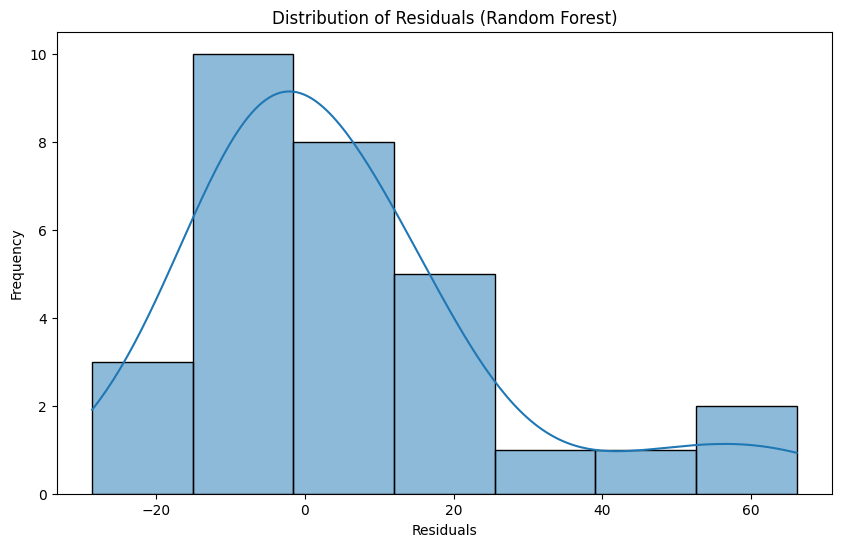

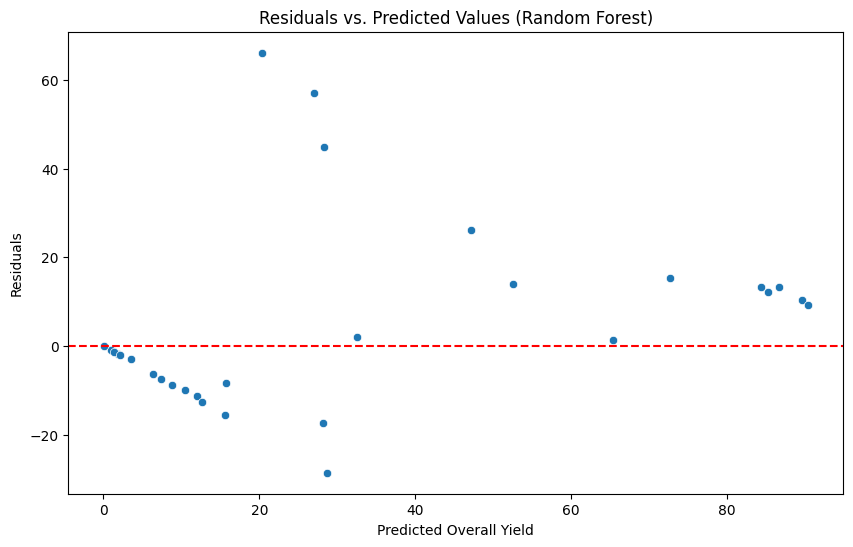

Top 5 instances with largest absolute errors (Random Forest):


,y_test,y_pred,residuals,abs_residuals
26,86.422,20.304865,66.117135,66.117135
143,83.985,26.960387,57.024613,57.024613
18,73.076,28.268268,44.807732,44.807732
30,0.146,28.715915,-28.569915,28.569915
12,73.187,47.136480,26.050520,26.050520


In [ ]:
# Calculate residuals for the Random Forest model
residuals_rf = y_test - y_pred_rf

plt.figure(figsize=(10, 6))
sns.histplot(residuals_rf, kde=True)
plt.title('Distribution of Residuals (Random Forest)')
plt.xlabel('Residuals')
plt.ylabel('Frequency')
plt.show()

plt.figure(figsize=(10, 6))
sns.scatterplot(x=y_pred_rf, y=residuals_rf)
plt.axhline(y=0, color='r', linestyle='--')
plt.title('Residuals vs. Predicted Values (Random Forest)')
plt.xlabel('Predicted Overall Yield')
plt.ylabel('Residuals')
plt.show()

# Identify instances with largest errors
error_df_rf = pd.DataFrame({'y_test': y_test, 'y_pred': y_pred_rf, 'residuals': residuals_rf})
error_df_rf['abs_residuals'] = np.abs(error_df_rf['residuals'])

print("Top 5 instances with largest absolute errors (Random Forest):")
display(error_df_rf.sort_values(by='abs_residuals', ascending=False).head())

### Model Training: Random Forest Regressor with RobustScaler and Polynomial Features

In [ ]:
from sklearn.preprocessing import PolynomialFeatures, RobustScaler

# Redefine the numerical transformer to include RobustScaler and PolynomialFeatures
numerical_transformer_poly = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='mean')),
    ('scaler', RobustScaler()), # Using RobustScaler as requested
    ('poly', PolynomialFeatures(degree=2, include_bias=False)) # Adding PolynomialFeatures
])

# Redefine the preprocessor with the new numerical transformer
preprocessor_poly = ColumnTransformer(
    transformers=[
        ('num', numerical_transformer_poly, X_train.columns) # Apply to all numerical features
    ])

print("Preprocessor updated with RobustScaler and PolynomialFeatures.")

Preprocessor updated with RobustScaler and PolynomialFeatures.


In [ ]:
# Create the model pipeline with the updated preprocessor
model_rf_poly = Pipeline(steps=[
    ('preprocessor', preprocessor_poly),
    ('regressor', RandomForestRegressor(random_state=SEED))
])

# Define the parameter distribution for RandomizedSearchCV (can reuse the previous one for RF)
# Note: max_features='auto' is deprecated in sklearn 1.2 and removed in 1.4.
# Using 'sqrt' as a robust alternative. 'None' means use all features.
param_dist_rf_poly = {
    'regressor__n_estimators': [100, 200, 300, 400, 500],
    'regressor__max_features': ['sqrt', 'log2', None],
    'regressor__max_depth': [10, 20, 30, 40, 50, None],
    'regressor__min_samples_split': [2, 5, 10],
    'regressor__min_samples_leaf': [1, 2, 4],
    'regressor__bootstrap': [True, False]
}

# Perform RandomizedSearchCV
random_search_rf_poly = RandomizedSearchCV(estimator=model_rf_poly, param_distributions=param_dist_rf_poly,
                                           n_iter=50, cv=5, verbose=2, random_state=SEED,
                                           n_jobs=-1, scoring='neg_root_mean_squared_error')

random_search_rf_poly.fit(X_train, y_train)

print("Best parameters found for RF with Polynomial Features: ", random_search_rf_poly.best_params_)
print("Best RMSE found for RF with Polynomial Features: ", -random_search_rf_poly.best_score_)

Fitting 5 folds for each of 50 candidates, totalling 250 fits
Best parameters found for RF with Polynomial Features:  {'regressor__n_estimators': 500, 'regressor__min_samples_split': 2, 'regressor__min_samples_leaf': 2, 'regressor__max_features': None, 'regressor__max_depth': 20, 'regressor__bootstrap': True}
Best RMSE found for RF with Polynomial Features:  23.841341948608097


In [ ]:
# Evaluate the best RF model with Polynomial Features on the test set
best_model_rf_poly = random_search_rf_poly.best_estimator_
y_pred_rf_poly = best_model_rf_poly.predict(X_test)

rmse_rf_poly = root_mean_squared_error(y_test, y_pred_rf_poly)
r2_rf_poly = r2_score(y_test, y_pred_rf_poly)

print(f"Random Forest Regressor (RobustScaler + Poly) RMSE on Test Set: {rmse_rf_poly}")
print(f"Random Forest Regressor (RobustScaler + Poly) R2 Score on Test Set: {r2_rf_poly}")

# Optional: You can now run error analysis on this model if it performs better

Random Forest Regressor (RobustScaler + Poly) RMSE on Test Set: 20.77321874299312
Random Forest Regressor (RobustScaler + Poly) R2 Score on Test Set: 0.7545917456562119


### Model Training: Linear Regressor with RobustScaler

In [ ]:
# Redefine the numerical transformer to include RobustScaler only for Linear Regression
numerical_transformer_robust = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='mean')),
    ('scaler', RobustScaler()) # Using RobustScaler
])

# Redefine the preprocessor with the new numerical transformer
preprocessor_robust = ColumnTransformer(
    transformers=[
        ('num', numerical_transformer_robust, X_train.columns) # Apply to all numerical features
    ])

print("Preprocessor updated with RobustScaler for Linear Regression.")

Preprocessor updated with RobustScaler for Linear Regression.


In [ ]:
# Create the model pipeline for Linear Regression with RobustScaler
model_lr_robust = Pipeline(steps=[
    ('preprocessor', preprocessor_robust),
    ('regressor', LinearRegression()) # Using LinearRegression
])

# Train the Linear Regression model
model_lr_robust.fit(X_train, y_train)

print("Linear Regression model with RobustScaler trained.")

Linear Regression model with RobustScaler trained.


In [ ]:
# Evaluate the Linear Regression model on the test set
y_pred_lr_robust = model_lr_robust.predict(X_test)

rmse_lr_robust = root_mean_squared_error(y_test, y_pred_lr_robust)
r2_lr_robust = r2_score(y_test, y_pred_lr_robust)

print(f"Linear Regressor (RobustScaler) RMSE on Test Set: {rmse_lr_robust}")
print(f"Linear Regressor (RobustScaler) R2 Score on Test Set: {r2_lr_robust}")

Linear Regressor (RobustScaler) RMSE on Test Set: 28.985185505112334
Linear Regressor (RobustScaler) R2 Score on Test Set: 0.5222136412775872


### Model Training: CatBoost Regressor with Randomized Search

In [ ]:
!pip install catboost
from catboost import CatBoostRegressor

# Create the model pipeline for CatBoost
model_cat = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('regressor', CatBoostRegressor(random_state=SEED, verbose=0)) # verbose=0 to suppress output
])

# Define a parameter distribution for RandomizedSearchCV for CatBoost
param_dist_cat = {
    'regressor__iterations': [100, 200, 300],
    'regressor__learning_rate': [0.01, 0.05, 0.1],
    'regressor__depth': [4, 6, 8],
    'regressor__l2_leaf_reg': [1, 3, 5],
    'regressor__subsample': [0.7, 0.8, 0.9] # For Bagging mode
}

# Perform RandomizedSearchCV
random_search_cat = RandomizedSearchCV(estimator=model_cat, param_distributions=param_dist_cat,
                                      n_iter=30, cv=5, verbose=2, random_state=SEED,
                                      n_jobs=-1, scoring='neg_root_mean_squared_error')

random_search_cat.fit(X_train, y_train)

print("Best parameters found for CatBoost: ", random_search_cat.best_params_)
print("Best RMSE found for CatBoost: ", -random_search_cat.best_score_)

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 97.1/97.1 MB 9.1 MB/s eta 0:00:00
Fitting 5 folds for each of 30 candidates, totalling 150 fits
Best parameters found for CatBoost:  {'regressor__subsample': 0.7, 'regressor__learning_rate': 0.1, 'regressor__l2_leaf_reg': 3, 'regressor__iterations': 300, 'regressor__depth': 6}
Best RMSE found for CatBoost:  21.363718511071134


In [ ]:
# Evaluate the best CatBoost model on the test set
best_model_cat = random_search_cat.best_estimator_
y_pred_cat = best_model_cat.predict(X_test)

rmse_cat = root_mean_squared_error(y_test, y_pred_cat)
r2_cat = r2_score(y_test, y_pred_cat)

print(f"CatBoost Regressor RMSE on Test Set: {rmse_cat}")
print(f"CatBoost Regressor R2 Score on Test Set: {r2_cat}")

CatBoost Regressor RMSE on Test Set: 19.594003556429964
CatBoost Regressor R2 Score on Test Set: 0.7816626963324531


### Model Training: LightGBM Regressor with Randomized Search

In [ ]:
from lightgbm import LGBMRegressor

# Create the model pipeline for LightGBM
model_lgbm = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('regressor', LGBMRegressor(random_state=SEED)) # Using LGBMRegressor
])

# Define a parameter distribution for RandomizedSearchCV for LightGBM
param_dist_lgbm = {
    'regressor__n_estimators': [100, 200, 300],
    'regressor__learning_rate': [0.01, 0.05, 0.1],
    'regressor__num_leaves': [20, 31, 40],
    'regressor__max_depth': [-1, 5, 10],
    'regressor__subsample': [0.7, 0.8, 0.9],
    'regressor__colsample_bytree': [0.7, 0.8, 0.9]
}

# Perform RandomizedSearchCV
random_search_lgbm = RandomizedSearchCV(estimator=model_lgbm, param_distributions=param_dist_lgbm,
                                       n_iter=30, cv=5, verbose=2, random_state=SEED,
                                       n_jobs=-1, scoring='neg_root_mean_squared_error')

random_search_lgbm.fit(X_train, y_train)

print("Best parameters found for LightGBM: ", random_search_lgbm.best_params_)
print("Best RMSE found for LightGBM: ", -random_search_lgbm.best_score_)

Fitting 5 folds for each of 30 candidates, totalling 150 fits


/usr/local/lib/python3.12/dist-packages/joblib/externals/loky/process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(


[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000070 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 621
[LightGBM] [Info] Number of data points in the train set: 120, number of used features: 15
[LightGBM] [Info] Start training from score 36.210950
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, b

In [ ]:
# Evaluate the best LightGBM model on the test set
best_model_lgbm = random_search_lgbm.best_estimator_
y_pred_lgbm = best_model_lgbm.predict(X_test)

rmse_lgbm = root_mean_squared_error(y_test, y_pred_lgbm)
r2_lgbm = r2_score(y_test, y_pred_lgbm)

print(f"LightGBM Regressor RMSE on Test Set: {rmse_lgbm}")
print(f"LightGBM Regressor R2 Score on Test Set: {r2_lgbm}")

LightGBM Regressor RMSE on Test Set: 22.33848083085666
LightGBM Regressor R2 Score on Test Set: 0.7162153848879207


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


### Ensemble Modeling: Averaging Predictions (XGBoost, CatBoost, LightGBM)

In [ ]:
# Ensure all best models are available from previous runs
# best_model_xgb is from d365dc35
# best_model_cat is from the cell above
# best_model_lgbm is from the cell above

# Get predictions from each model
# Assuming y_pred_xgb, y_pred_cat, y_pred_lgbm are already computed for the test set
# If not, re-run prediction from best_estimator_ for each model

# For robustness, let's re-predict using the best estimators explicitly
y_pred_xgb_ensemble = grid_search_xgb.best_estimator_.predict(X_test)
y_pred_cat_ensemble = random_search_cat.best_estimator_.predict(X_test)
y_pred_lgbm_ensemble = random_search_lgbm.best_estimator_.predict(X_test)

# Average the predictions
y_pred_ensemble = (y_pred_xgb_ensemble + y_pred_cat_ensemble + y_pred_lgbm_ensemble) / 3

# Evaluate the ensemble model
rmse_ensemble = root_mean_squared_error(y_test, y_pred_ensemble)
r2_ensemble = r2_score(y_test, y_pred_ensemble)

print(f"Ensemble Model (XGBoost, CatBoost, LightGBM Averaging) RMSE on Test Set: {rmse_ensemble}")
print(f"Ensemble Model (XGBoost, CatBoost, LightGBM Averaging) R2 Score on Test Set: {r2_ensemble}")

Ensemble Model (XGBoost, CatBoost, LightGBM Averaging) RMSE on Test Set: 20.613316786609094
Ensemble Model (XGBoost, CatBoost, LightGBM Averaging) R2 Score on Test Set: 0.7583552673874708


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


### Model Training: Support Vector Regressor (SVR) with Randomized Search

In [ ]:
from sklearn.svm import SVR

# Redefine the numerical features and standard preprocessor for SVR
# This ensures 'preprocessor' is defined even if previous cells were not run
numerical_features = X_train.columns
numerical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='mean')),
    ('scaler', StandardScaler())
])

preprocessor = ColumnTransformer(
    transformers=[
        ('num', numerical_transformer, numerical_features)
    ])

# Create the model pipeline for SVR
# Using the standard preprocessor (with StandardScaler) as SVMs are sensitive to feature scaling
model_svr = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('regressor', SVR()) # Using SVR
])

# Define a parameter distribution for RandomizedSearchCV for SVR
param_dist_svr = {
    'regressor__kernel': ['linear', 'poly', 'rbf', 'sigmoid'],
    'regressor__C': np.logspace(-1, 2, 4), # Example: [0.1, 1, 10, 100]
    'regressor__gamma': ['scale', 'auto'] + list(np.logspace(-3, 0, 4)), # Example: [0.001, 0.01, 0.1, 1]
    'regressor__epsilon': [0.1, 0.2, 0.5] # For SVR loss function
}

# Perform RandomizedSearchCV
random_search_svr = RandomizedSearchCV(estimator=model_svr, param_distributions=param_dist_svr,
                                      n_iter=30, cv=5, verbose=2, random_state=SEED,
                                      n_jobs=-1, scoring='neg_root_mean_squared_error')

random_search_svr.fit(X_train, y_train)

print("Best parameters found for SVR: ", random_search_svr.best_params_)
print("Best RMSE found for SVR: ", -random_search_svr.best_score_)

Fitting 5 folds for each of 30 candidates, totalling 150 fits
Best parameters found for SVR:  {'regressor__kernel': 'rbf', 'regressor__gamma': 'auto', 'regressor__epsilon': 0.1, 'regressor__C': np.float64(100.0)}
Best RMSE found for SVR:  23.604537632044018


In [ ]:
# Evaluate the best SVR model on the test set
best_model_svr = random_search_svr.best_estimator_
y_pred_svr = best_model_svr.predict(X_test)

rmse_svr = root_mean_squared_error(y_test, y_pred_svr)
r2_svr = r2_score(y_test, y_pred_svr)

print(f"SVR Regressor RMSE on Test Set: {rmse_svr}")
print(f"SVR Regressor R2 Score on Test Set: {r2_svr}")

SVR Regressor RMSE on Test Set: 25.82691972228179
SVR Regressor R2 Score on Test Set: 0.6206616045173882


In [ ]:
model_performance = pd.DataFrame({
    'Model': [
        'Random Forest Regressor',
        'XGBoost Regressor',
        'Ridge Regressor',
        'Random Forest Regressor (RobustScaler + Poly)',
        'Linear Regressor (RobustScaler)',
        'CatBoost Regressor',
        'LightGBM Regressor',
        'Ensemble Model (XGBoost, CatBoost, LightGBM)',
        'SVR Regressor'
    ],
    'RMSE': [
        rmse_rf,
        rmse_xgb,
        rmse_ridge,
        rmse_rf_poly,
        rmse_lr_robust,
        rmse_cat,
        rmse_lgbm,
        rmse_ensemble,
        rmse_svr
    ],
    'R2 Score': [
        r2_rf,
        r2_xgb,
        r2_ridge,
        r2_rf_poly,
        r2_lr_robust,
        r2_cat,
        r2_lgbm,
        r2_ensemble,
        r2_svr
    ]
})

model_performance = model_performance.sort_values(by='RMSE').reset_index(drop=True)
display(model_performance)

,Model,RMSE,R2 Score
0,CatBoost Regressor,19.594004,0.781663
1,"Ensemble Model (XGBoost, CatBoost, LightGBM)",20.613317,0.758355
2,Random Forest Regressor (RobustScaler + Poly),20.773219,0.754592
3,Random Forest Regressor,21.179387,0.744901
4,XGBoost Regressor,21.624607,0.734063
5,LightGBM Regressor,22.338481,0.716215
6,SVR Regressor,25.826920,0.620662
7,Linear Regressor (RobustScaler),28.985186,0.522214
8,Ridge Regressor,29.213848,0.514645


In [ ]:
best_model = model_performance.loc[model_performance['RMSE'].idxmin()]
print(f"The best performing model based on RMSE is: {best_model['Model']} with an RMSE of {best_model['RMSE']:.2f}")

The best performing model based on RMSE is: CatBoost Regressor with an RMSE of 19.59
